# Code Walkthrough: Feature Matching and Robust Fitting

We've covered feature detection, description, and matching (lectures 13-14), and robust model fitting with Hough transforms and RANSAC (lecture 17) -- all on clean, controlled examples. Today we build a small, real pipeline end to end, on a real photo:

- **Part A:** detect corners, describe them, and match two views of the same scene.
- **Part B:** robustly fit a line and a circle to real, cluttered edge points with RANSAC.

As before, some cells are filled in already (recapping things we've already built in lecture); the `TASK` cells left blank are yours to fill in, with your AI assistant, as we go.

## Part A: Feature Detection, Description, and Matching

### 1. Load a real photo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate2d
from scipy.ndimage import gaussian_filter, map_coordinates, maximum_filter

IMAGES_DIR = Path("./../src-marimo/images")

def to_grayscale(img_rgb):
    weights = np.array([0.2989, 0.5870, 0.1140])  # standard R, G, B luminance weights
    return img_rgb @ weights

image_name = "coffee"
img_rgb = plt.imread(IMAGES_DIR / f"{image_name}.png")[:, :, :3].astype(np.float64) * 255.0
gray_A = to_grayscale(img_rgb)
H, W = gray_A.shape
print(f"image size: {H} x {W}")

image size: 400 x 600


**TASK:** Display the grayscale image.

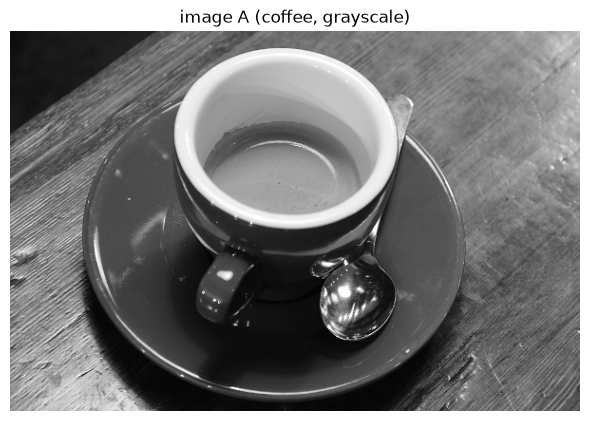

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(gray_A, cmap="gray")
ax.set_title(f"image A ({image_name}, grayscale)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 2. Create a second view of the scene

We don't have two separate photos of this exact cup from two angles. So we reuse the trick from lecture 14: warp the *same* photo by a small, **known** rotation + translation to synthesize "image B." This gives us a second view to match against, and a ground truth we can use later to check whether our matches are actually correct.

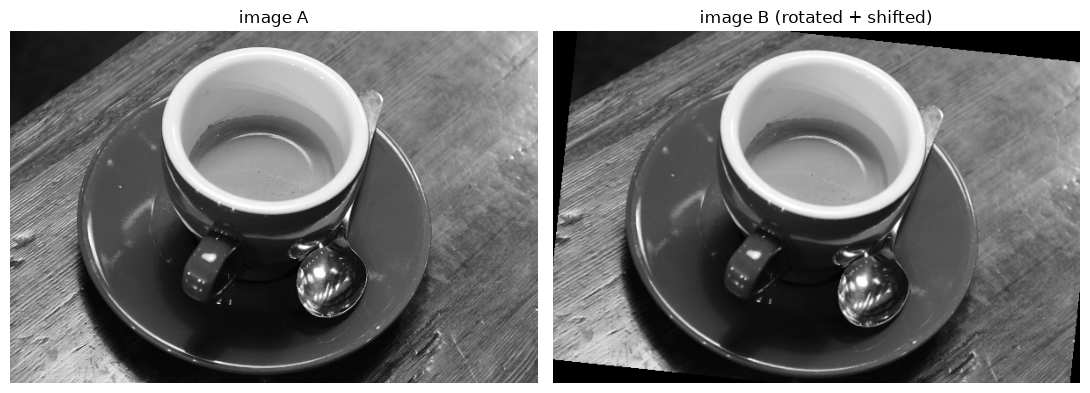

In [5]:
def make_second_view(img_gray, theta_deg, tx, ty):
    """Warp img_gray by a small known rotation (about its center) + translation.
    Returns the warped image and the 3x3 homography H used to produce it."""
    H_img, W_img = img_gray.shape
    theta = np.radians(theta_deg)
    ct, st = np.cos(theta), np.sin(theta)
    cx, cy = W_img / 2, H_img / 2
    R = np.array([[ct, -st, tx], [st, ct, ty], [0, 0, 1]])
    T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]])
    T2 = np.array([[1, 0, cx], [0, 1, cy], [0, 0, 1]])
    Hmat = T2 @ R @ T1
    Hinv = np.linalg.inv(Hmat)
    yy, xx = np.mgrid[0:H_img, 0:W_img].astype(float)
    coords = np.stack([xx.ravel(), yy.ravel(), np.ones(H_img * W_img)])
    src = Hinv @ coords
    src_x = (src[0] / src[2]).reshape(H_img, W_img)
    src_y = (src[1] / src[2]).reshape(H_img, W_img)
    warped = map_coordinates(img_gray, [src_y, src_x], order=1, mode="constant", cval=0.0)
    return warped, Hmat

gray_B, H_true = make_second_view(gray_A, theta_deg=6, tx=8, ty=5)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(gray_A, cmap="gray"); axes[0].set_title("image A"); axes[0].axis("off")
axes[1].imshow(gray_B, cmap="gray"); axes[1].set_title("image B (rotated + shifted)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

### 3. Detect corners (Harris)

**TASK:** Recall the Harris corner response from lecture 13: $R = \det(A) - 0.06\,\mathrm{trace}(A)^2$, where $A$ is the gradient-based structure tensor. Rebuild it here.

**TASK:** Extract a list of corner points from a response map: keep local maxima above a fraction of the map's peak value.

corners in A: 85, corners in B: 87


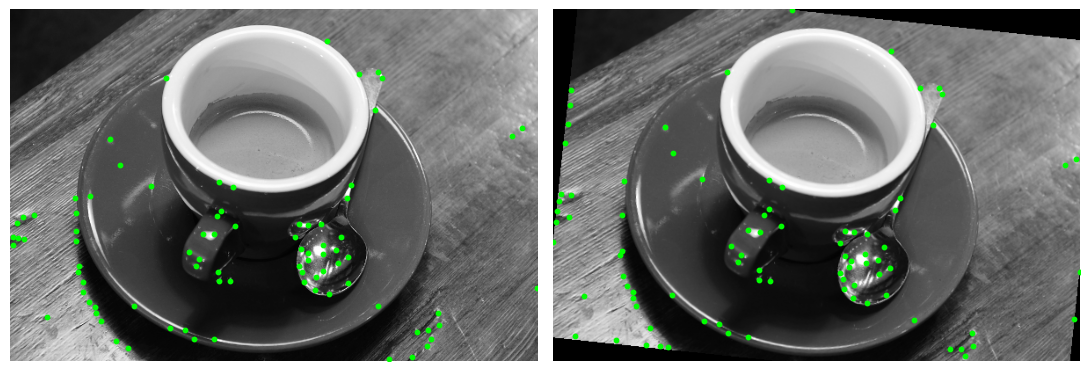

In [5]:
def corner_points(R, max_pts=200, thresh_frac=0.01):
    thresh = thresh_frac * R.max()
    local_max = (R == maximum_filter(R, size=9)) & (R > thresh)
    ys, xs = np.nonzero(local_max)
    order = np.argsort(-R[ys, xs])[:max_pts]
    return xs[order], ys[order]

R_A = harris_response(gray_A)
R_B = harris_response(gray_B)
xs_A, ys_A = corner_points(R_A)
xs_B, ys_B = corner_points(R_B)
print(f"corners in A: {len(xs_A)}, corners in B: {len(xs_B)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(gray_A, cmap="gray"); axes[0].scatter(xs_A, ys_A, s=10, c="lime"); axes[0].axis("off")
axes[1].imshow(gray_B, cmap="gray"); axes[1].scatter(xs_B, ys_B, s=10, c="lime"); axes[1].axis("off")
plt.tight_layout()
plt.show()

### 4. Describe each corner (normalized patch)

**TASK:** Recall the bias/gain-normalized patch descriptor from lecture 14 §1: a small patch around each point, rescaled to zero mean and unit variance so it's robust to brightness/contrast differences between the two images.

In [6]:
def patch_descriptor(img_gray, x, y, half=8):
    H_img, W_img = img_gray.shape
    if x - half < 0 or x + half >= W_img or y - half < 0 or y + half >= H_img:
        return None
    patch = img_gray[y - half:y + half, x - half:x + half]
    return (patch - patch.mean()) / (patch.std() + 1e-6)

def describe_points(img_gray, xs, ys, half=8):
    descs, pts = [], []
    for x, y in zip(xs, ys):
        d = patch_descriptor(img_gray, x, y, half)
        if d is not None:
            descs.append(d.ravel())
            pts.append((x, y))
    return np.array(descs), pts

desc_A, pts_A = describe_points(gray_A, xs_A, ys_A)
desc_B, pts_B = describe_points(gray_B, xs_B, ys_B)
print(f"descriptors A: {desc_A.shape}, descriptors B: {desc_B.shape}")

descriptors A: (79, 256), descriptors B: (78, 256)


### 5. Match descriptors (NNDR) -- your turn

**TASK:** Write a function `nndr_match(desc_A, desc_B, threshold)` that, for each descriptor in A, finds its nearest and second-nearest neighbor in B (Euclidean distance) and keeps the match only if the nearest-neighbor distance ratio is below the threshold:

$$ \frac{d_1}{d_2} < \text{threshold} $$

Return a list of `(i, j)` index pairs (into `pts_A` and `pts_B`). A threshold around 0.8 is a reasonable place to start (Eq. 7.18).

**TASK:** Visualize the matches: draw a line between each matched pair of points across the two images. Since image B came from a *known* transform (`H_true`), check each match's correctness by projecting its image-A point through `H_true` and measuring how close it lands to the matched point in B (say, within 3 pixels). Color correct matches green, incorrect ones red, and report how many of each you got.

## Part B: Robust Fitting with RANSAC on a Real Photo

Lecture 17's RANSAC demo used clean synthetic points. Real images are messier: edge detection on a real photo produces plenty of genuine clutter (wood grain, reflections, unrelated objects) alongside the feature you actually care about. We'll look at two crops of the same photo: one containing a real straight edge (the edge of the table), one containing a real circular object (the rim of the cup).

### 1. Extract real, cluttered edge points

line crop: 3358 edge points; circle crop: 3700 edge points


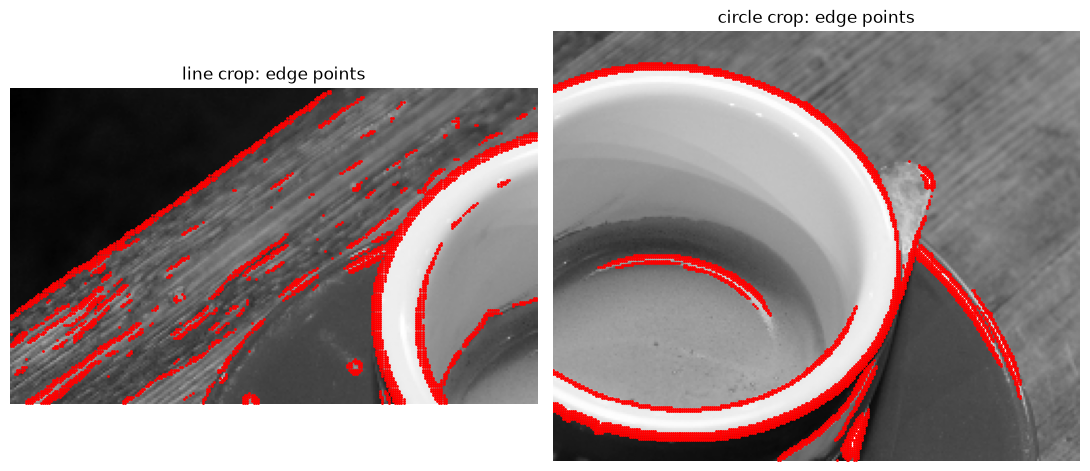

In [7]:
# Two regions of the same photo, picked by hand: one with a real straight
# edge, one with a real circular object.
line_crop = gray_A[0:150, 0:250]
circle_crop = gray_A[0:220, 230:500]

def edge_points(img_gray, mag_thresh):
    Ix, Iy = gradients(img_gray, 1.0)
    mag = np.hypot(Ix, Iy)
    ys, xs = np.nonzero(mag > mag_thresh)
    return np.stack([xs, ys], axis=1).astype(float)

line_pts = edge_points(line_crop, mag_thresh=10)
circle_pts = edge_points(circle_crop, mag_thresh=15)
print(f"line crop: {len(line_pts)} edge points; circle crop: {len(circle_pts)} edge points")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(line_crop, cmap="gray"); axes[0].scatter(line_pts[:, 0], line_pts[:, 1], s=1, c="red")
axes[0].set_title("line crop: edge points"); axes[0].axis("off")
axes[1].imshow(circle_crop, cmap="gray"); axes[1].scatter(circle_pts[:, 0], circle_pts[:, 1], s=1, c="red")
axes[1].set_title("circle crop: edge points"); axes[1].axis("off")
plt.tight_layout()
plt.show()

### 2. Fit a line with RANSAC -- your turn

**TASK:** Implement RANSAC line fitting from scratch, per lecture 17 §3 (Eqs. 8.28-8.30): repeatedly (1) randomly sample 2 points and fit a line $y = mx + b$ through them, (2) count **inliers** -- points within $\epsilon$ of the line, using the point-to-line distance $|y_i - (mx_i+b)| / \sqrt{1+m^2}$ -- (3) keep whichever trial has the most inliers, then (4) refit $(m, b)$ using *all* of that trial's inliers (plain least squares) for your final answer. Apply it to `line_pts`.

**TASK:** Now extend the same recipe to circles. A circle needs a minimal sample of **3** points instead of 2. Given 3 points, the circle through them has center $(u_x, u_y)$ and radius $r$:

$$ u_x = \frac{(a_x^2+a_y^2)(b_y-c_y) + (b_x^2+b_y^2)(c_y-a_y) + (c_x^2+c_y^2)(a_y-b_y)}{d}, \quad u_y = \frac{(a_x^2+a_y^2)(c_x-b_x) + (b_x^2+b_y^2)(a_x-c_x) + (c_x^2+c_y^2)(b_x-a_x)}{d} $$

with $d = 2\big(a_x(b_y-c_y) + b_x(c_y-a_y) + c_x(a_y-b_y)\big)$ and $r = \|(a_x,a_y) - (u_x,u_y)\|$, for sample points $a, b, c$. The inlier test is now distance-to-the-circle's-boundary: $\big|\,\|p_i - (u_x,u_y)\| - r\,\big| < \epsilon$. Apply it to `circle_pts` (hint: restricting candidate radii to a plausible range, e.g. 50-130 pixels, helps avoid degenerate fits).

**TASK:** Visualize both fits: show each crop with its edge points colored green (inlier) / red (outlier), and draw the fitted line and circle on top.

## Wrap-up

You just built, from scratch, a full applied pipeline on a real photo: **detect → describe → match** (Part A) and **robust fit** (Part B). The same two ideas show up constantly in practice -- feature matching underlies panorama stitching and AR marker tracking; robust fitting underlies lane detection, document deskewing, and part/defect measurement -- always on data messier than a textbook figure, which is exactly why the robustness (NNDR's ratio test, RANSAC's outlier rejection) matters.